### Уравнение теплопроводности

$\frac{\partial{u}}{\partial{t}} = \frac{\partial}{\partial{x}}k(x)\frac{\partial{u}}{\partial{x}}$

#### Граничные условия:

$u(0,t) = 1$

$\frac{\partial{u}}{\partial{x}}(L,t) = 0$

#### Начальные условия:

$u(x,0) = 0$


#### Параметры задачи:

$L = 1$ - длина стержня

$k(x) = k_0(1+\frac{1}{2}sin(2\pi x))$ - теплопроводность материала

### FTCS-схема

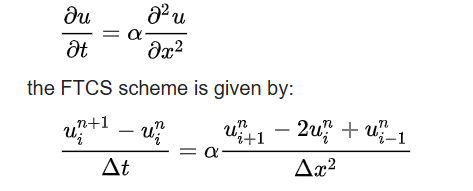

Устойчивость схемы:

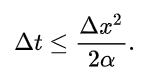

### Схема Кранка-Николсона

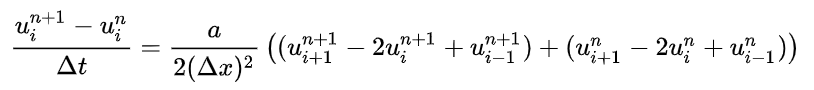

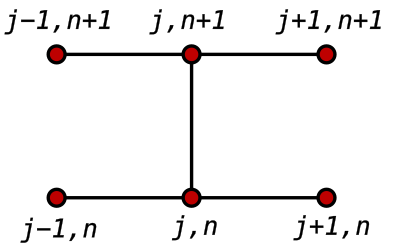

In [ ]:
#Импорт зависимостей
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from scipy.sparse import diags, csr_matrix, linalg as spla
from imageio import v2 as imageio
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import factorized
from IPython.display import HTML
from matplotlib import animation

In [ ]:
#Параметры задачи
OUTDIR = "results"
os.makedirs(OUTDIR, exist_ok=True)

L1 = 1.0
k0_1d = 1e-2

u_left_value = 1.0
plot_times_1d = [0.01, 0.1, 0.5]

Lx2, Ly2 = 1.0, 1.0
k0_2d = 1e-2

HEAT_CENTER_RADIUS = 0.02 

In [ ]:
#Функции теплопроводности
def k1d(x): 
    return k0_1d * (1.0 + 0.5 * np.sin(2*pi*x))

def k2d(X, Y):
    return k0_2d * (1.0 + 0.5 * np.sin(2*pi*X) * np.sin(2*pi*Y))

#Вычисление полной энергии
def total_energy_1d(u, dx):
    return np.sum(u) * dx

In [ ]:
#Сохранение графиков
def save_plot_1d(x, series, labels, title, fname):
    plt.figure(figsize=(8,4))
    for arr, lab in zip(series, labels):
        plt.plot(x, arr, label=lab, linewidth=2)
    plt.xlabel('x')
    plt.ylabel('u(x,t)')
    plt.title(title)
    plt.legend(); plt.grid(True)
    plt.tight_layout()
    plt.savefig(fname, dpi=150)
    plt.close()

In [ ]:
#Реализация схемы FTCS
def ftcs_1d(L, Nx, dt, t_final, kfunc, u_left=1.0):
    dx = L/(Nx-1)
    x = np.linspace(0, L, Nx)
    kx = kfunc(x)
    k_half = 0.5*(kx[:-1] + kx[1:])
    u = np.zeros_like(x)
    u[0] = u_left
    n_steps = int(np.ceil(t_final/dt))
    snapshots = {}
    t = 0.0
    for n in range(n_steps):
        un = u.copy()
        for i in range(1, Nx-1):
            flux_r = k_half[i]*(un[i+1] - un[i]) / dx
            flux_l = k_half[i-1]*(un[i] - un[i-1]) / dx
            u[i] = un[i] + dt/dx*(flux_r - flux_l)
        u[0] = u_left
        u[-1] = u[-2]  
        t += dt
        for pt in plot_times_1d:
            if abs(t - pt) <= dt/2 and pt not in snapshots:
                snapshots[pt] = u.copy()
    return x, u, snapshots

In [ ]:
#Реализация схемы Crank-Nicolson
def crank_nicolson_1d(L, Nx, dt, t_final, kfunc, u_left=1.0):
    dx = L/(Nx-1)
    x = np.linspace(0, L, Nx)
    kx = kfunc(x)
    k_half = 0.5*(kx[:-1] + kx[1:])
    r = dt/(2*dx*dx)
    N = Nx
    lower_A = np.zeros(N)
    diag_A  = np.ones(N)
    upper_A = np.zeros(N)
    lower_B = np.zeros(N)
    diag_B  = np.ones(N)
    upper_B = np.zeros(N)
    diag_A[0] = 1.0; diag_B[0] = 1.0
    for i in range(1, N-1):
        k_p = k_half[i]
        k_m = k_half[i-1]
        diag_A[i] = 1 + r*(k_p + k_m)
        lower_A[i] = - r * k_m
        upper_A[i] = - r * k_p
        diag_B[i] = 1 - r*(k_p + k_m)
        lower_B[i] = r * k_m
        upper_B[i] = r * k_p
    i = N-1
    k_p = 0.0
    k_m = k_half[i-1]
    diag_A[i] = 1 + r*(k_m + k_p)
    lower_A[i] = - r * k_m
    upper_A[i] = 0.0
    diag_B[i] = 1 - r*(k_m + k_p)
    lower_B[i] = r * k_m
    upper_B[i] = 0.0
    # Thomas solver for tri-diagonal A
    def thomas(a, b, c, d):
        n = len(d)
        cp = np.zeros(n); dp = np.zeros(n)
        xout = np.zeros(n)
        cp[0] = c[0] / b[0]
        dp[0] = d[0] / b[0]
        for i in range(1, n):
            denom = b[i] - a[i]*cp[i-1]
            cp[i] = c[i]/denom if i < n-1 else 0.0
            dp[i] = (d[i] - a[i]*dp[i-1]) / denom
        xout[-1] = dp[-1]
        for i in range(n-2, -1, -1):
            xout[i] = dp[i] - cp[i]*xout[i+1]
        return xout
    u = np.zeros(N); u[0] = u_left
    snapshots = {}
    t = 0.0
    n_steps = int(np.ceil(t_final/dt))
    for n in range(n_steps):
        rhs = np.zeros(N)
        rhs[0] = u_left
        for i in range(1, N-1):
            rhs[i] = lower_B[i]*u[i-1] + diag_B[i]*u[i] + upper_B[i]*u[i+1]
        rhs[N-1] = lower_B[N-1]*u[N-2] + diag_B[N-1]*u[N-1]
        u = thomas(lower_A, diag_A, upper_A, rhs)
        u[0] = u_left
        u[-1] = u[-2]
        t += dt
        for pt in plot_times_1d:
            if abs(t - pt) <= dt/2 and pt not in snapshots:
                snapshots[pt] = u.copy()
    return x, u, snapshots

In [ ]:
#Запуск одномерной задачи
def run_1d():
    Nx = 201
    x = np.linspace(0, L1, Nx)
    max_k = np.max(k1d(np.linspace(0,L1,2001)))
    dx = L1/(Nx-1)
    dt_explicit = 0.4 * dx*dx / max_k 
    dt_cn = dt_explicit  
    t_final = max(plot_times_1d)
    t0 = time.time()
    x_e, u_e, snaps_e = ftcs_1d(L1, Nx, dt_explicit, t_final, k1d, u_left=u_left_value)
    x_c, u_c, snaps_c = crank_nicolson_1d(L1, Nx, dt_cn, t_final, k1d, u_left=u_left_value)
    t1 = time.time()
    for pt in plot_times_1d:
        s_e = snaps_e.get(pt, None)
        s_c = snaps_c.get(pt, None)
        labels = []
        series = []
        if s_e is not None:
            labels.append("FTCS")
            series.append(s_e)
        if s_c is not None:
            labels.append("Crank–Nicolson")
            series.append(s_c)
        if series:
            fname = os.path.join("results", f"temperature_1d_t{pt:.3f}.png")
            save_plot_1d(x, series, labels, f"Профиль температуры t={pt:.3f}", fname)
    times_e, energies_e = energies_over_time_1d(ftcs_1d, L1, Nx, dt_explicit, t_final, k1d, sample_every=1)
    times_c, energies_c = energies_over_time_1d(crank_nicolson_1d, L1, Nx, dt_cn, t_final, k1d, sample_every=1)
    plt.figure(figsize=(6,4))
    plt.plot(times_e, energies_e, label='FTCS')
    plt.plot(times_c, energies_c, label='Crank–Nicolson')
    plt.xlabel('t'); plt.ylabel('Общая энергия'); plt.legend(); plt.grid(True)
    plt.title('Зависимость энергии от температуры (1D)')
    fname = os.path.join("results", "energies_1d.png")
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.close()
    dx_ref = 1.0/800 
    dt_ref = 0.4 * dx_ref*dx_ref / max_k
    x_ref, u_ref, _ = crank_nicolson_1d(L1, int(L1/dx_ref)+1, dt_ref, t_final=0.5, kfunc=k1d, u_left=u_left_value)
    dx_list = [1/50, 1/100, 1/200, 1/400]
    errors = []
    hs = []
    for dx_i in dx_list:
        Nx_i = int(L1/dx_i)+1
        dt_i = 0.4 * dx_i*dx_i / max_k
        x_i, u_i, _ = ftcs_1d(L1, Nx_i, dt_i, 0.5, k1d, u_left=u_left_value)
        u_ref_interp = np.interp(x_i, x_ref, u_ref)
        err = np.sqrt(np.sum((u_i - u_ref_interp)**2) * dx_i)
        errors.append(err); hs.append(dx_i)
        print(f"dx={dx_i:.5f}, err_L2={err:.3e}")
    p = np.polyfit(np.log(hs), np.log(errors), 1)[0]
    print(f"Оцененный порядок по пространству: p = {p:.2f}")
    with open(os.path.join("results", "convergence_1d.txt"), "w") as f:
        f.write("dx\tL2_error\n")
        for h,e in zip(hs, errors):
            f.write(f"{h}\t{e}\n")
        f.write(f"p_estimated={p}\n")


In [ ]:
#Вычисление энергии 1D
def energies_over_time_1d(scheme_func, L, Nx, dt, t_final, kfunc, sample_every=1):
    dx = L/(Nx-1); x = np.linspace(0,L,Nx)
    u = np.zeros_like(x); u[0] = u_left_value
    max_k = np.max(kfunc(np.linspace(0,L,1001)))
    n_steps = int(np.ceil(t_final/dt))
    times=[]; energies=[]
    t=0.0
    if scheme_func == ftcs_1d:
        kx = kfunc(x); k_half = 0.5*(kx[:-1]+kx[1:])
        for n in range(n_steps):
            un = u.copy()
            for i in range(1, Nx-1):
                flux_r = k_half[i]*(un[i+1]-un[i])/ (L/(Nx-1))
                flux_l = k_half[i-1]*(un[i]-un[i-1])/ (L/(Nx-1))
                u[i] = un[i] + dt/(L/(Nx-1))*(flux_r - flux_l)
            u[0]=u_left_value; u[-1]=u[-2]
            t += dt
            if n % sample_every == 0 or abs(t - t_final) < 1e-12:
                times.append(t); energies.append(total_energy_1d(u, L/(Nx-1)))
    else:
        _, u_final, snaps = scheme_func(L, Nx, dt, t_final, kfunc, u_left=u_left_value)
        times = [t_final]; energies = [total_energy_1d(u_final, L/(Nx-1))]
    return np.array(times), np.array(energies)

In [ ]:
#Профиль сердца
def heart_mask(X, Y, scale=1.0):
    scale = 1.5         
    x0, y0 = 0.5, 0.5 
    xs = (X - x0) * 2 * scale
    ys = (Y - y0) * 2 * scale
    val = (xs**2 + ys**2 - 1.0)**3 - xs**2 * ys**3
    return val <= 0

In [ ]:
#FTCS
def ftcs_2d(Lx, Ly, Nx, Ny, dt, t_final, kfunc_2d, initial_u, dirichlet_edges=True, source_center=True):
    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y, indexing='xy')
    kxy = kfunc_2d(X, Y)
    kx_half = 0.5 * (kxy[:, :-1] + kxy[:, 1:])  # (Ny, Nx-1)
    ky_half = 0.5 * (kxy[:-1, :] + kxy[1:, :])  # (Ny-1, Nx)
    U = initial_u.copy()
    n_steps = int(np.ceil(t_final / dt))
    frames = []
    t = 0.0
    for n in range(n_steps):
        U_new = U.copy()
        for j in range(1, Ny - 1):
            for i in range(1, Nx - 1):
                termx = (kx_half[j, i] * (U[j, i + 1] - U[j, i]) -
                         kx_half[j, i - 1] * (U[j, i] - U[j, i - 1])) / dx**2
                termy = (ky_half[j, i] * (U[j + 1, i] - U[j, i]) -
                         ky_half[j - 1, i] * (U[j, i] - U[j - 1, i])) / dy**2
                U_new[j, i] = U[j, i] + dt * (termx + termy)
        if dirichlet_edges:
            U_new[0, :] = 0
            U_new[-1, :] = 0
            U_new[:, 0] = 0
            U_new[:, -1] = 0
        if source_center:
            cx, cy = Nx // 2, Ny // 2
            rsrc = max(1, int(0.02 / dx))
            U_new[cy - rsrc:cy + rsrc + 1, cx - rsrc:cx + rsrc + 1] = 1.0
        U = U_new
        t += dt
        if (n % max(1, n_steps // 50) == 0) or abs(t - t_final) < 1e-12:
            frames.append((t, U.copy()))
    return x, y, frames

In [ ]:
#Crank-Nicolson
def crank_nicolson_2d(Lx, Ly, Nx, Ny, dt, t_final, kfunc_2d, initial_u, dirichlet_edges=True, source_center=True):
    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y, indexing='xy')
    kxy = kfunc_2d(X, Y)
    kx_half = 0.5 * (kxy[:, :-1] + kxy[:, 1:])
    ky_half = 0.5 * (kxy[:-1, :] + kxy[1:, :])
    N = Nx * Ny
    def idx(j, i): return j * Nx + i
    rows, cols, data = [], [], []
    rowsB, colsB, dataB = [], [], []
    r = dt / 2.0
    for j in range(Ny):
        for i in range(Nx):
            p = idx(j, i)
            if dirichlet_edges and (i==0 or i==Nx-1 or j==0 or j==Ny-1):
                rows.append(p); cols.append(p); data.append(1.0)
                rowsB.append(p); colsB.append(p); dataB.append(1.0)
                continue
            diagL = 0.0
            stencil = []
            # влево
            km = kx_half[j, i-1]
            stencil.append((idx(j, i-1), km / dx**2))
            diagL -= km / dx**2
            # вправо
            kp = kx_half[j, i]
            stencil.append((idx(j, i+1), kp / dx**2))
            diagL -= kp / dx**2
            # вниз
            kb = ky_half[j-1, i]
            stencil.append((idx(j-1, i), kb / dy**2))
            diagL -= kb / dy**2
            # вверх
            kt = ky_half[j, i]
            stencil.append((idx(j+1, i), kt / dy**2))
            diagL -= kt / dy**2
            # Матрицы A = I - (dt/2)L, B = I + (dt/2)L
            rows.append(p); cols.append(p); data.append(1.0 - r * diagL)
            rowsB.append(p); colsB.append(p); dataB.append(1.0 + r * diagL)
            for (pj, Lj) in stencil:
                rows.append(p); cols.append(pj); data.append(-r * Lj)
                rowsB.append(p); colsB.append(pj); dataB.append(r * Lj)
    A = csr_matrix((data, (rows, cols)), shape=(N, N))
    B = csr_matrix((dataB, (rowsB, colsB)), shape=(N, N))
    solveA = factorized(A)
    u_old = initial_u.reshape(N)
    n_steps = int(np.ceil(t_final / dt))
    frames = []
    t = 0.0
    for n in range(n_steps):
        b = B @ u_old
        u_new = solveA(b)
        U = u_new.reshape((Ny, Nx))
        if dirichlet_edges:
            U[0,:] = 0; U[-1,:] = 0; U[:,0] = 0; U[:,-1] = 0
        if source_center:
            cx, cy = Nx // 2, Ny // 2
            rsrc = max(1, int(0.02 / dx))
            U[cy - rsrc:cy + rsrc + 1, cx - rsrc:cx + rsrc + 1] = np.maximum(
                U[cy - rsrc:cy + rsrc + 1, cx - rsrc:cx + rsrc + 1], 1.0)
        u_old = U.reshape(N)
        t += dt
        if (n % max(1, n_steps // 50) == 0) or abs(t - t_final) < 1e-12:
            frames.append((t, U.copy()))
    return x, y, frames

In [ ]:
#Анимации
def frames_to_jshtml(frames, extent=(0,1,0,1), cmap='hot', interval=80, figsize=(5,5), title_prefix="t="):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_axis_off()
    first_t, first_U = frames[0]
    im = ax.imshow(first_U, origin='lower', extent=extent, cmap=cmap)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    title = ax.set_title(f"{title_prefix} {first_t:.3f}")
    def update(i):
        t, U = frames[i]
        im.set_data(U)
        title.set_text(f"{title_prefix} {t:.3f}")
        return (im, title)
    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=interval, blit=False)
    js = anim.to_jshtml()
    plt.close(fig)
    return HTML(js)

In [ ]:
#Запуск 2D
def run_2d():
    Nx = 101
    Ny = 101
    Lx, Ly = Lx2, Ly2
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)
    X, Y = np.meshgrid(x, y, indexing='xy')
    mask = heart_mask(X, Y, scale=0.9)
    u0 = np.zeros_like(X)
    u0[mask] = 0.5
    cx = Nx // 2
    cy = Ny // 2
    r = max(1, int(HEAT_CENTER_RADIUS / (Lx / (Nx - 1))))
    u0[cy - r:cy + r + 1, cx - r:cx + r + 1] = 1.0
    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)
    max_k = np.max(k2d(X, Y))
    dt_explicit = 0.25 * min(dx, dy) ** 2 / max_k
    t_final = 2.0
    t0 = time.time()
    xe, ye, frames_e = ftcs_2d(
        Lx, Ly, Nx, Ny, dt_explicit, t_final,
        k2d, u0, dirichlet_edges=True, source_center=True
    )
    t1 = time.time()
    fnames = []
    for i, (t, u) in enumerate(frames_e):
        fname = os.path.join(OUTDIR, f"2d_ftcs_t{i:03d}.png")
        plt.figure(figsize=(5, 4))
        plt.imshow(u, origin='lower', extent=[0, Lx, 0, Ly], cmap='hot')
        plt.colorbar(label='Температура')
        plt.title(f"FTCS (явная)  t={t:.3f}")
        plt.tight_layout()
        plt.savefig(fname, dpi=150)
        plt.close()
        fnames.append(fname)
    gif_name = os.path.join(OUTDIR, "2d_ftcs.gif")
    images = [imageio.imread(fn) for fn in fnames]
    imageio.mimsave(gif_name, images, duration=0.08)
    dt_impl = 0.01
    t0 = time.time()
    xi, yi, frames_i = crank_nicolson_2d(
        Lx, Ly, Nx, Ny, dt_impl, t_final,
        k2d, u0, dirichlet_edges=True, source_center=True
    )
    t1 = time.time()
    fnames_i = []
    for i, (t, u) in enumerate(frames_i):
        fname = os.path.join(OUTDIR, f"2d_cn_t{i:03d}.png")
        plt.figure(figsize=(5, 4))
        plt.imshow(u, origin='lower', extent=[0, Lx, 0, Ly], cmap='hot')
        plt.colorbar(label='Температура')
        plt.title(f"Crank–Nicolson t={t:.3f}")
        plt.tight_layout()
        plt.savefig(fname, dpi=150)
        plt.close()
        fnames_i.append(fname)
    gif_name_i = os.path.join(OUTDIR, "2d_cn.gif")
    images = [imageio.imread(fn) for fn in fnames_i]
    imageio.mimsave(gif_name_i, images, duration=0.08)
    display(frames_to_jshtml(frames_i, extent=[0,Lx,0,Ly], cmap='hot', interval=80, title_prefix='Кранк-Николсон t='))
    display(frames_to_jshtml(frames_e, extent=[0,Lx,0,Ly], cmap='hot', interval=80, title_prefix='FTCS t='))
    

In [ ]:
#main
if __name__ == "__main__":
    run_1d()
    run_2d()

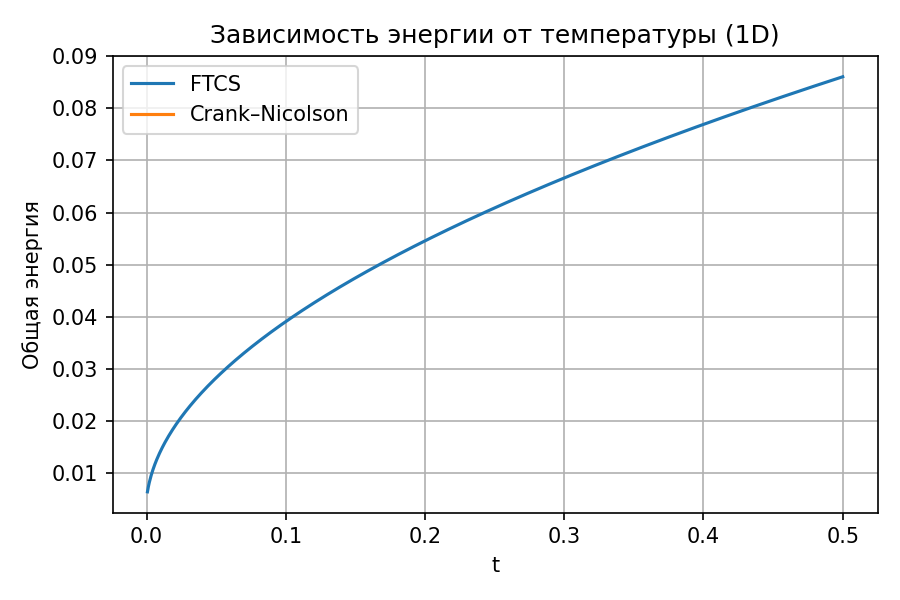

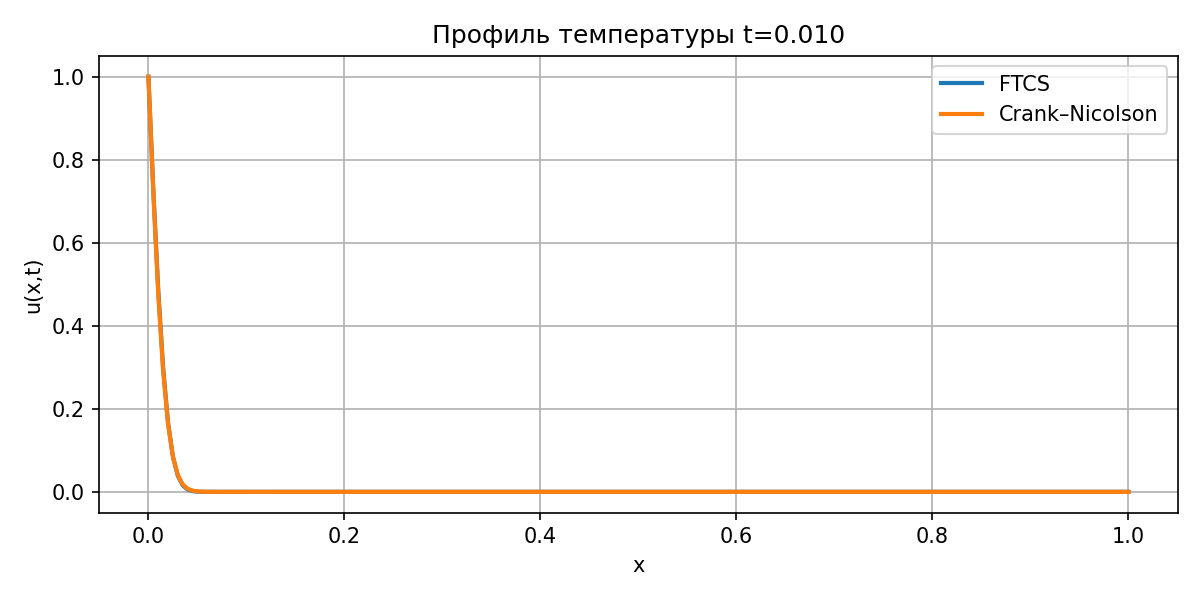

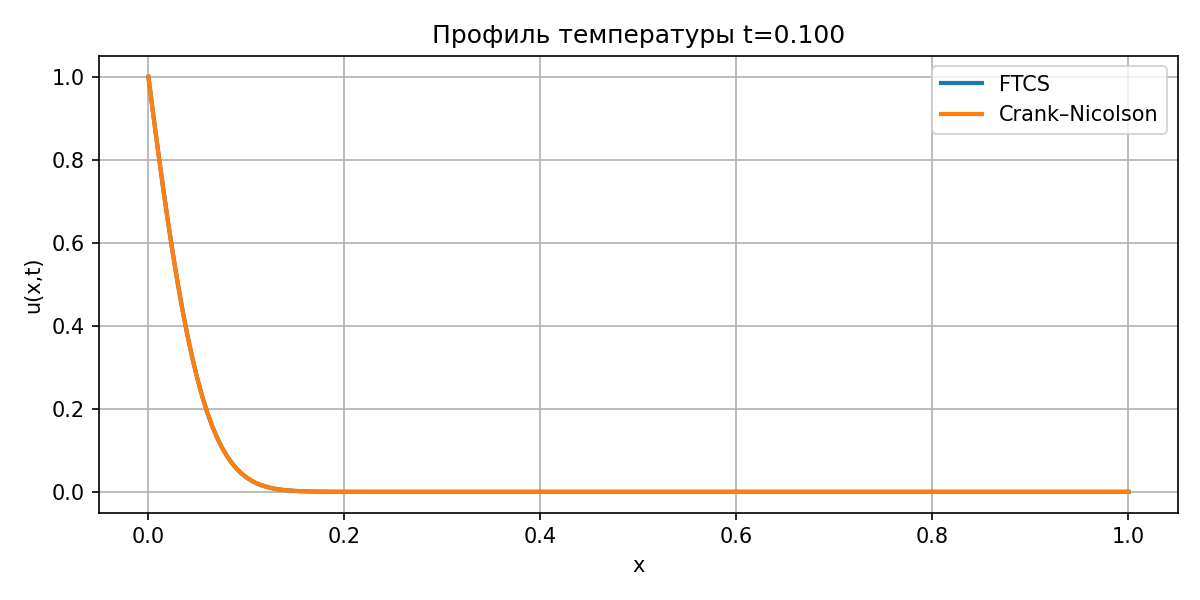

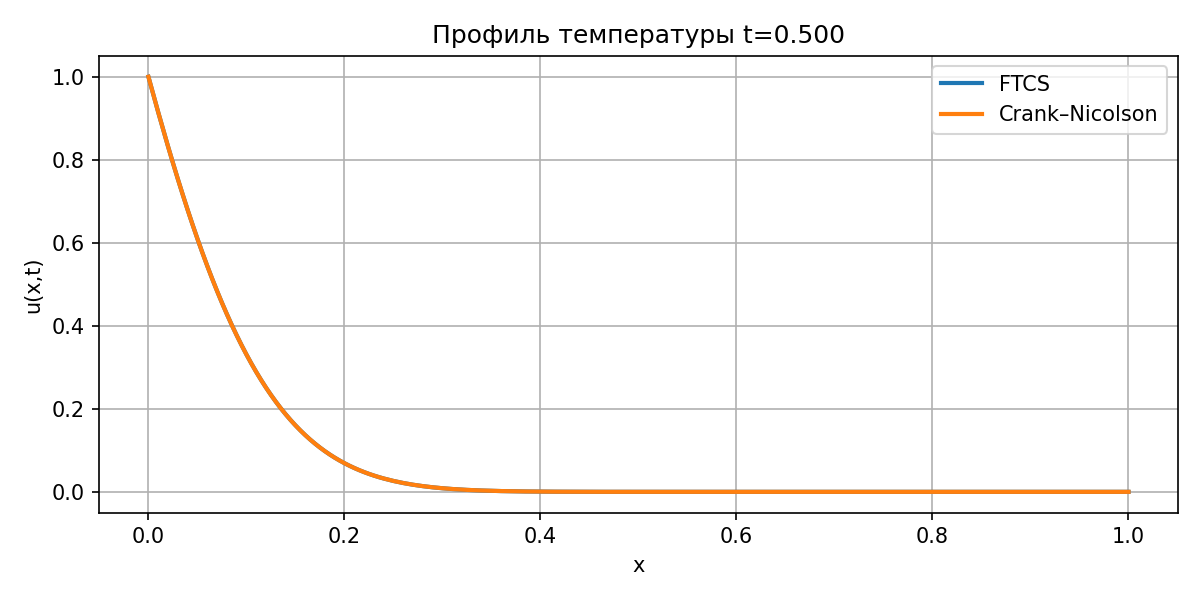